<center>


<div style="display: flex; justify-content: center;">
    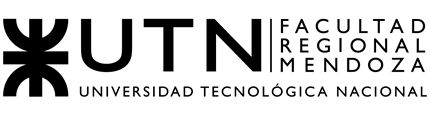
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Ingeniería en Electrónica</strong></p>
        <p><strong>Ingeniería en Telecomunicaciones</strong></p>
    </div>
</center>

# Módulo 3 — Colecciones

Hasta acá trabajamos con variables que guardan **un solo valor** a la vez: un número, un texto, un booleano. Pero en la práctica casi siempre necesitamos agrupar varios valores bajo un mismo nombre: las muestras de una señal, los parámetros de un componente, las frecuencias detectadas en un análisis.

Python ofrece cuatro **colecciones** básicas, cada una pensada para un tipo distinto de agrupación:

| Colección | ¿Ordenada? | ¿Mutable? | Típicamente se usa para... |
|-----------|-----------|-----------|---------------------------|
| **Lista** (*list*) | sí | sí | secuencias de valores que pueden cambiar |
| **Tupla** (*tuple*) | sí | no | grupos fijos de valores |
| **Diccionario** (*dict*) | sí | sí | pares **clave → valor** |
| **Conjunto** (*set*) | no | sí | elementos únicos, sin duplicados |

En este módulo vamos a ver cómo crear, acceder y modificar cada una de ellas.

## 1. Listas

Una **lista** (*list*) es una secuencia ordenada de valores. Se escribe entre corchetes `[ ]`, con los elementos separados por comas:

In [ ]:
mediciones = [3.1, 3.2, 2.9, 3.3, 3.0]
print(mediciones)
print(type(mediciones))

Los elementos pueden ser de cualquier tipo — incluso mezclados dentro de la misma lista — aunque en la mayoría de los casos una lista tiene todos los elementos del mismo tipo:

In [ ]:
# Una lista con tipos mezclados (válido, pero poco habitual)
info = ["resistor", 220, 0.05, True]
print(info)

### 1.1 Acceso por índice

A cada elemento de la lista le corresponde un **índice** que indica su posición. **Python numera desde cero**: el primer elemento es el `[0]`, el segundo el `[1]`, y así sucesivamente.

In [ ]:
mediciones = [3.1, 3.2, 2.9, 3.3, 3.0]
print(mediciones[0])   # primer elemento
print(mediciones[2])   # tercer elemento

También se pueden usar **índices negativos** para contar desde el final: `-1` es el último elemento, `-2` el anteúltimo, y así:

In [ ]:
print(mediciones[-1])  # último
print(mediciones[-2])  # anteúltimo

> **Nota:** si pedís un índice que no existe (por ejemplo `mediciones[10]` cuando la lista tiene 5 elementos), Python lanza un error: `IndexError: list index out of range`. Es un error clásico — cuando lo veas, contá bien los elementos de tu lista.

La función `len()` devuelve la **cantidad de elementos** de una lista:

In [ ]:
print(len(mediciones))

### Actividad 1: primer contacto con listas

Imaginá que registraste la temperatura ambiente cada hora durante 6 horas y obtuviste los siguientes valores (en °C): `18.5, 19.0, 20.1, 21.3, 20.8, 19.4`.

1. Guardá esos valores en una lista llamada `temperaturas`.
2. Mostrá con `print()` la primera y la última medición.
3. Mostrá también cuántas mediciones hay, usando `len()`.

In [ ]:
# TU CÓDIGO AQUÍ

## 2. Slicing: tomar tramos de una lista

Muchas veces no nos interesa un elemento aislado sino **un tramo** de la lista (por ejemplo, los primeros 100 puntos de una señal). Para eso Python usa una sintaxis llamada **slicing** (rebanado):

```
lista[inicio:fin]
```

Esto devuelve una **nueva** lista con los elementos desde el índice `inicio` **hasta el `fin`, sin incluirlo**.

In [ ]:
señal = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
print(señal[2:5])   # elementos en los índices 2, 3 y 4
print(señal[0:3])   # los tres primeros

Si se omite `inicio`, se asume el comienzo; si se omite `fin`, se asume el final. Eso da formas muy limpias de escribir "los primeros N" o "desde cierto punto en adelante":

In [ ]:
print(señal[:3])    # los tres primeros
print(señal[7:])    # desde el índice 7 hasta el final
print(señal[:])     # una copia de toda la lista

Se puede agregar un tercer número, el **paso**:

```
lista[inicio:fin:paso]
```

Por ejemplo, para tomar un elemento cada dos, o para recorrer la lista al revés:

In [ ]:
print(señal[::2])    # uno de cada dos: 0, 2, 4, 6, 8
print(señal[1::2])   # uno de cada dos, arrancando en 1: 1, 3, 5, 7, 9
print(señal[::-1])   # la lista al revés

> **Idea clave.** El patrón "tomar uno de cada N" se llama **submuestreo**, y es una operación fundamental en procesamiento de señales. Por ahora alcanza con que te resulte familiar la sintaxis; el concepto lo vamos a desarrollar más adelante.

### Actividad 2: recortar una señal

Dada esta lista que representa 10 muestras consecutivas de una señal:

```python
muestras = [0.0, 0.3, 0.6, 0.9, 1.0, 0.9, 0.6, 0.3, 0.0, -0.3]
```

1. Guardá en `primera_mitad` las cinco primeras muestras.
2. Guardá en `segunda_mitad` las cinco últimas.
3. Guardá en `pares` las muestras que están en índices pares (0, 2, 4, ...).

Mostrá las tres con `print()`.

In [ ]:
muestras = [0.0, 0.3, 0.6, 0.9, 1.0, 0.9, 0.6, 0.3, 0.0, -0.3]

# TU CÓDIGO AQUÍ

## 3. Modificar listas

Las listas son **mutables**: se pueden cambiar después de creadas. La forma más directa es reemplazar un elemento por su índice:

In [ ]:
valores = [10, 20, 30, 40]
valores[1] = 99
print(valores)

Además, las listas tienen **métodos** para agregar, quitar o insertar elementos. Un método se llama con la sintaxis `objeto.metodo(...)`:

| Método | Qué hace |
|--------|----------|
| `lista.append(x)` | agrega `x` al final |
| `lista.insert(i, x)` | inserta `x` en el índice `i`, corriendo el resto a la derecha |
| `lista.remove(x)` | quita la **primera** aparición de `x` |
| `lista.pop()` | saca y devuelve el último elemento |
| `lista.pop(i)` | saca y devuelve el elemento del índice `i` |

In [ ]:
valores = [10, 20, 30]
valores.append(40)
print(valores)               # [10, 20, 30, 40]

valores.insert(1, 15)
print(valores)               # [10, 15, 20, 30, 40]

ultimo = valores.pop()
print("Saqué:", ultimo)
print(valores)               # [10, 15, 20, 30]

valores.remove(15)
print(valores)               # [10, 20, 30]

### Concatenar y repetir

Los operadores `+` y `*` también funcionan sobre listas:

In [ ]:
a = [1, 2, 3]
b = [4, 5]
print(a + b)        # concatenar
print([0] * 5)      # repetir: [0, 0, 0, 0, 0]

El segundo patrón es muy útil para **inicializar** una lista de cierto tamaño con un valor por defecto (por ejemplo, un vector de ceros).

### Actividad 3: corregir y ampliar mediciones

Partiendo de estas mediciones de tensión (en volts):

```python
tensiones = [12.1, 12.3, 999.0, 12.0, 12.2]
```

1. El valor `999.0` es un error de lectura: reemplazalo (usando su índice) por `12.1`.
2. Agregá al final una nueva medición: `12.4`.
3. Mostrá la lista final y su longitud.

In [ ]:
tensiones = [12.1, 12.3, 999.0, 12.0, 12.2]

# TU CÓDIGO AQUÍ

## 4. Funciones útiles sobre listas numéricas

Cuando la lista contiene números, hay varias funciones integradas de Python que permiten obtener resúmenes rápidos:

| Función | Devuelve |
|---------|----------|
| `len(lista)` | cantidad de elementos |
| `sum(lista)` | suma de todos los elementos |
| `min(lista)` | menor valor |
| `max(lista)` | mayor valor |
| `sorted(lista)` | una **nueva** lista con los elementos ordenados de menor a mayor |

In [ ]:
temperaturas = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]
print("n        =", len(temperaturas))
print("mínima   =", min(temperaturas))
print("máxima   =", max(temperaturas))
print("promedio =", sum(temperaturas) / len(temperaturas))
print("ordenadas:", sorted(temperaturas))

## 5. Pertenencia: el operador `in`

Para saber si un valor está presente en una colección, se usa el operador `in`, que devuelve un booleano:

In [ ]:
frecuencias = [50, 100, 150, 200]
print(100 in frecuencias)     # True
print(75  in frecuencias)     # False
print(75 not in frecuencias)  # True

## 6. Tuplas

Una **tupla** (*tuple*) es como una lista pero **inmutable**: una vez creada, sus elementos no se pueden cambiar, agregar ni quitar. Se escribe con paréntesis en lugar de corchetes:

In [ ]:
punto = (3.0, 4.0)
print(punto)
print(type(punto))
print(punto[0], punto[1])   # el acceso por índice funciona igual que en una lista

Si intentás modificar un elemento, Python lanza un error:

```python
punto[0] = 5.0
# TypeError: 'tuple' object does not support item assignment
```

### ¿Para qué usar tuplas si las listas pueden hacer lo mismo y más?

Justamente porque **no cambian**. Cuando un grupo de valores forma una unidad conceptual que no tiene sentido modificar — un par `(x, y)`, un color `(R, G, B)`, una fecha `(año, mes, día)` — usar una tupla deja claro en el código que esos valores van juntos y no se tocan.

### Desempacado de tuplas

Una tupla se puede **desempacar** en varias variables en una sola línea, si la cantidad coincide:

In [ ]:
punto = (3.0, 4.0)
x, y = punto
print(f"x = {x}, y = {y}")

Este patrón es muy cómodo y vas a verlo seguido — por ejemplo, cuando una función devuelve varios valores a la vez.

### Actividad 4: una tupla para un componente

Un capacitor se caracteriza típicamente por tres valores: su capacitancia (en µF), su tensión máxima (en V) y su tolerancia (en %). Supongamos que tenemos un capacitor de `10 µF`, `25 V`, tolerancia `5 %`.

1. Guardá esos tres valores, en ese orden, en una tupla llamada `capacitor`.
2. Desempacala en tres variables: `capacidad`, `tension_max` y `tolerancia`.
3. Mostrá con un f-string el mensaje: `Capacitor: 10 µF / 25 V (±5%)`, usando las variables (no los números a mano).

In [ ]:
# TU CÓDIGO AQUÍ

## 7. Diccionarios

Un **diccionario** (*dict*) asocia **claves** con **valores**. Se escribe con llaves `{ }`, y cada par clave-valor se separa con dos puntos. Las claves deben ser únicas dentro del diccionario.

In [ ]:
resistor = {
    "nombre": "R1",
    "valor": 220,
    "unidad": "ohm",
    "tolerancia": 5,
}
print(resistor)
print(type(resistor))

Para acceder al valor asociado a una clave se usa `diccionario[clave]`:

In [ ]:
print(resistor["valor"])
print(resistor["unidad"])

Si pedís una clave que no existe, Python lanza un `KeyError`. Para **consultar** si una clave está presente, usá el operador `in`:

In [ ]:
print("valor"    in resistor)   # True
print("potencia" in resistor)   # False

### Agregar, modificar y quitar

Un diccionario es mutable: la misma sintaxis de asignación sirve tanto para **modificar** un valor existente como para **agregar** una clave nueva. La palabra clave `del` quita una entrada.

In [ ]:
resistor["tolerancia"] = 1      # modifica un valor existente
resistor["potencia"]   = 0.25   # agrega una nueva clave
print(resistor)

del resistor["unidad"]
print(resistor)

### Las tres vistas de un diccionario

Todo diccionario ofrece tres "vistas" que vas a usar seguido:

- `dict.keys()` → las claves
- `dict.values()` → los valores
- `dict.items()` → los pares `(clave, valor)` como tuplas

In [ ]:
print(list(resistor.keys()))
print(list(resistor.values()))
print(list(resistor.items()))

> **Nota:** envolvimos cada vista en `list(...)` solo para que se imprima como una lista común. Para **recorrer** un diccionario elemento por elemento se usa un bucle `for`, que se presenta en el Módulo 4.

### Actividad 5: ficha de un componente

Vas a armar la "ficha" de un LED rojo:

1. Creá un diccionario `led` con las claves `"color"` (valor: `"rojo"`), `"tension"` (valor: `2.0`) y `"corriente"` (valor: `0.02`).
2. Agregale una clave `"potencia"` cuyo valor se calcule como `tension * corriente`, usando los valores que ya están guardados en el diccionario (recordá: `led["tension"]`, `led["corriente"]`).
3. Mostrá el diccionario completo con `print()`.

In [ ]:
# TU CÓDIGO AQUÍ

## 8. Conjuntos

Un **conjunto** (*set*) es una colección **sin duplicados** y **sin orden definido**. Se escribe con llaves, pero con elementos sueltos (no pares):

In [ ]:
frecuencias = {50, 100, 150, 200, 100, 50}
print(frecuencias)   # los duplicados se descartan automáticamente
print(type(frecuencias))

> **Cuidado con las llaves vacías:** `{}` **no** crea un conjunto vacío sino un diccionario vacío. Para el conjunto vacío se usa `set()`.

Una de las aplicaciones más útiles es **obtener los elementos únicos** de una lista, pasándola por `set()`:

In [ ]:
mediciones = [50, 60, 50, 100, 60, 200, 50]
unicas = set(mediciones)
print(unicas)

### Operaciones entre conjuntos

Los conjuntos soportan las operaciones habituales de la teoría de conjuntos:

| Operación | Sintaxis |
|-----------|----------|
| Unión | `A \| B` |
| Intersección | `A & B` |
| Diferencia | `A - B` |

In [ ]:
A = {1, 2, 3, 4}
B = {3, 4, 5, 6}
print("Unión:       ", A | B)
print("Intersección:", A & B)
print("Diferencia:  ", A - B)

También se pueden agregar y quitar elementos con `.add()` y `.remove()`, y preguntar por pertenencia con `in`:

In [ ]:
frecuencias = {50, 100, 150}
frecuencias.add(200)
print(frecuencias)
print(100 in frecuencias)

### Actividad 6: frecuencias únicas

En un análisis detectaste las siguientes frecuencias (en Hz), con repeticiones:

```python
detectadas = [50, 120, 50, 240, 120, 360, 50, 240]
```

1. Obtené las frecuencias únicas como un conjunto llamado `unicas`.
2. Mostrá cuántas frecuencias distintas hay (`len()` también funciona sobre conjuntos).
3. Verificá con `in` si la frecuencia `60` fue detectada; mostrá el resultado.

In [ ]:
detectadas = [50, 120, 50, 240, 120, 360, 50, 240]

# TU CÓDIGO AQUÍ

## 9. Un vistazo al recorrido de colecciones

Las colecciones muestran todo su poder cuando podés **recorrerlas** elemento por elemento. La herramienta para eso es el bucle `for`, que se presenta en detalle en el próximo módulo. Como anticipo — mirá qué fácil es sumar todas las temperaturas de una lista con un `for`:

In [ ]:
temperaturas = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]

total = 0
for t in temperaturas:
    total = total + t

print("Suma:    ", total)
print("Promedio:", total / len(temperaturas))

No hace falta que entiendas la sintaxis del `for` todavía — la idea es solo que veas que el bucle va "agarrando" uno por uno los elementos de la lista y los mete en la variable `t` para hacer algo con ellos. En el Módulo 4 lo vemos con calma.

## Cierre

En este módulo viste las cuatro colecciones básicas de Python:

- **Listas** (`[...]`): secuencias ordenadas y mutables; se acceden por índice y permiten *slicing*.
- **Tuplas** (`(...)`): secuencias ordenadas pero **inmutables**; útiles para agrupar datos que van juntos.
- **Diccionarios** (`{clave: valor}`): mapean claves a valores; ideales para armar "fichas" de datos.
- **Conjuntos** (`{a, b, c}` o `set(...)`): colecciones **sin duplicados**, con operaciones de unión, intersección y diferencia.

También viste el operador `in` para preguntar por pertenencia, y funciones integradas como `len()`, `sum()`, `min()`, `max()` y `sorted()` para operar sobre listas numéricas.

**En el próximo módulo** vamos a ver las **estructuras de control** (`if`, `for`, `while`): las herramientas para que un programa tome decisiones y repita operaciones. Recién ahí las colecciones de este módulo se van a poder explotar en todo su potencial.